In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path(r"C:\Users\Vivian\Documents\CONCH")
sys.path.insert(0, str(PROJECT_ROOT))

from conch.open_clip_custom import create_model_from_pretrained, tokenize, get_tokenizer
import torch
import os
from PIL import Image
from pathlib import Path

# show all jupyter output
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

c:\Users\Vivian\anaconda3\envs\conch\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
model_cfg = 'conch_ViT-B-16'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# checkpoint_path = 'checkpoints/CONCH/pytorch_model.bin'
checkpoint_path = 'C:\\Users\\Vivian\\Documents\\CONCH\\checkpoints\\conch\\pytorch_model.bin' 
# checkpoint_path = r"C:\Users\Vivian\Documents\CONCH\_finetune_weights\fine_tuned_model2.pth" # testing with finetuned conch model
model, preprocess = create_model_from_pretrained(model_cfg, checkpoint_path, device=device)
_ = model.eval()

C:\Users\Vivian\Documents\CONCH\conch\open_clip_custom\factory.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=map

In [3]:
# import torch
from transformers import AutoTokenizer
tokenizer = get_tokenizer()

In [3]:
# CONFIGS
# 2.5x -> 10x TOPK SELECTION + 10x GATED MIL
#
# Assumptions (based on what you said):
# - 10x deep coords are on a 224 grid in level-0 pixel coords (or equivalent).
# - 2.5x coords are downsampled by 4 in linear scale vs 10x, so parent bin = 224*4 = 896.
# - You already have a helper block that sets SLIDE_COL / LABEL_COL etc.
#
# What this script does:
# 1) Load df10 concept CSV (for gating concepts) and df25 concept CSV (for TOPK selection prior)
# 2) For each slide: load 10x deep (Xd, coords10)
# 3) Map each 10x coord -> parent 2.5x coord bin and compute a scalar score from 2.5x concepts
# 4) Apply BAG_CAP (random) then TOPK by that 2.5x-derived score
# 5) Build Xc (gating concepts) from df10 aligned by (x,y)
# 6) Train/eval gated MIL across folds
# ============================================================

# %% =========================
# IMPORTS
# =========================
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, accuracy_score
import h5py

# %% =========================
# CONFIG (EDIT THESE)
# =========================
CV_ROOT = r"C:/Users/Vivian/Documents/PANTHER/PANTHER/src/splits/cross-val"                  # fold dirs with train/val/test.csv

FEAT_BACKEND = "pt"                # "pt" or "h5"
# PT_FEAT_DIR = r"C:\Users\Vivian\Documents\CONCH\conch_img_feats\10x_feats\conchextracted_mag10x_patch224_fp\feats_pt"        # 10x deep feature pt dir
PT_FEAT_DIR = r'C:\Users\Vivian\Documents\CONCH\conch_img_feats\2.5x_feats\40x\pt' # 2.5x feature pt dir (for selection prior)
H5_FEAT_DIR = None                 # set if FEAT_BACKEND="h5"

# PATCH_CONCEPT_CSV_10 =  r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\noCAP_patch_ptfile_notopk_conf_PATCH.csv"     # your 10x (or 40x etc) concept CSV aligned to 10x deep coords
PATCH_CONCEPT_CSV_10 = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\2.5x\noCAP_patch_ptfile_notopk_conf_PATCH.csv"      # your 2.5x concept CSV (coords on 896 grid)

PATCH_CONCEPT_CSV_25 = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\2.5x\noCAP_patch_ptfile_notopk_conf_PATCH.csv"      # your 2.5x concept CSV (coords on 896 grid)
# PATCH_CONCEPT_CSV_25 =  r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\noCAP_patch_ptfile_notopk_conf_PATCH.csv"     # your 10x (or 40x etc) concept CSV aligned to 10x deep coords

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 0

EPOCHS = 8
LR = 1e-3
WEIGHT_DECAY = 1e-4
HID = 128
DROPOUT = 0.1

BAG_CAP = None     # random cap BEFORE topk (None to disable)
TOPK = None         # keep top-k 10x patches scored by 2.5x prior (None to disable)

# grid / mapping
STRIDE_10 = 224
DS_10_TO_25 = 4
REGION_BIN = STRIDE_10 * DS_10_TO_25   # 896

# selection scoring from 2.5x concept vector
SELECT_SCORE_MODE = "mean_all"         # "mean_all" | "mean_subset" | "max_subset"
SELECT_SUBSET_COLS = None              # e.g. ["concept_3","concept_17"] if using subset modes

# gate concept source: use 10x concepts for gating (recommended)
GATE_SOURCE = "10x"                    # only "10x" supported in this script
SELECTION_SOURCE = "10x"   # "2.5x" or "10x" or "deep"
USE_25_ATTN = False   # you’re adding Xc25 term

APPLY_SLIDE_NORM_C10 = False

OUT_DIR = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\slide_preds_2.5x" # output dir for slide-level concept scores and labels (for MIL training)
os.makedirs(OUT_DIR, exist_ok=True)



In [4]:
# YOUR HELPER BLOCK 
# =========================================================
SLIDE_COL = "slide_id"
LABEL_COL = "true_label_str"
X_COL = "x"
Y_COL = "y"
CONCEPT_PREFIX = "concept_"

# %% =========================
# HELPERS
# =========================
def labels_to_int(arr):
    s = pd.Series(arr).astype(str).str.upper().str.strip()
    y = s.map({"FA": 0, "PT": 1})
    if y.isna().any():
        raise ValueError(f"Bad labels: {s[y.isna()].unique()}")
    return y.astype(int).to_numpy()

def read_slide_list(csv_path: str):
    d = pd.read_csv(csv_path)
    if "slide" in d.columns:
        slides = d["slide"].astype(str).tolist()
    elif "slide_id" in d.columns:
        slides = d["slide_id"].astype(str).tolist()
    else:
        slides = d.iloc[:, 0].astype(str).tolist()
    return [os.path.splitext(s.strip())[0] for s in slides]

def find_fold_dirs(cv_root: str):
    out = []
    for name in sorted(os.listdir(cv_root)):
        p = os.path.join(cv_root, name)
        if os.path.isdir(p) and all(os.path.isfile(os.path.join(p, f"{x}.csv")) for x in ["train","val","test"]):
            out.append(p)
    return out

def eval_metrics(y_true, y_prob, thr=0.5):
    y_true = np.asarray(y_true, dtype=float)
    y_prob = np.asarray(y_prob, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_prob)
    if mask.sum() == 0:
        return {"auc": np.nan, "balacc": np.nan, "acc": np.nan}
    y_true = y_true[mask].astype(int)
    y_prob = y_prob[mask]
    y_pred = (y_prob >= thr).astype(int)
    auc = np.nan
    if len(np.unique(y_true)) == 2:
        auc = roc_auc_score(y_true, y_prob)
    return {
        "auc": auc,
        "balacc": balanced_accuracy_score(y_true, y_pred),
        "acc": accuracy_score(y_true, y_pred),
    }

def summarize_percent(df_metrics, cols=("auc","balacc","acc")):
    out = {}
    for c in cols:
        m = df_metrics[c].mean() * 100.0
        s = df_metrics[c].std(ddof=1) * 100.0
        out[c] = (round(m, 2), round(s, 2))
    return out

def parent_bin_xy(x10: int, y10: int, bin_size: int):
    x25 = (int(x10) // bin_size) * bin_size
    y25 = (int(y10) // bin_size) * bin_size
    return x25, y25

def reduce_score(v: np.ndarray, mode: str, subset_idxs=None):
    if mode == "mean_all":
        return float(v.mean())
    if subset_idxs is None:
        raise ValueError("subset_idxs required for subset modes")
    if mode == "mean_subset":
        return float(v[subset_idxs].mean())
    if mode == "max_subset":
        return float(v[subset_idxs].max())
    raise ValueError(f"Bad SELECT_SCORE_MODE: {mode}")

# %% =========================
# DEEP LOADER (10x)
# =========================
def load_slide_deep_with_coords(slide_id: str):
    if FEAT_BACKEND == "pt":
        pt_path = os.path.join(PT_FEAT_DIR, f"{slide_id}.pt")
        if not os.path.isfile(pt_path):
            raise FileNotFoundError(pt_path)
        obj = torch.load(pt_path, map_location="cpu")
        if not isinstance(obj, dict) or "features" not in obj or "coords" not in obj:
            raise ValueError(f"Expected dict with keys 'features','coords' in {pt_path}. Got {type(obj)} {getattr(obj,'keys',lambda:[])()}")
        feats = obj["features"].float().numpy()
        coords = obj["coords"].int().numpy()
        return feats.astype(np.float32), coords.astype(np.int32)

    if FEAT_BACKEND == "h5":
        if not H5_FEAT_DIR:
            raise ValueError("Set H5_FEAT_DIR when FEAT_BACKEND='h5'")
        h5_path = os.path.join(H5_FEAT_DIR, f"{slide_id}.h5")
        if not os.path.isfile(h5_path):
            raise FileNotFoundError(h5_path)
        with h5py.File(h5_path, "r") as f:
            feats = f["features"][:] if "features" in f else f["feats"][:]
            coords = f["coords"][:]
        return feats.astype(np.float32), coords.astype(np.int32)

    raise ValueError(f"Bad FEAT_BACKEND={FEAT_BACKEND}")

# %% =========================
# LOAD CONCEPT TABLES
# =========================
def load_concept_df(path: str):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    for col in [SLIDE_COL, LABEL_COL, X_COL, Y_COL]:
        if col not in df.columns:
            raise ValueError(f"Missing '{col}' in {path}. Columns={df.columns.tolist()}")
    concept_cols = [c for c in df.columns if c.startswith(CONCEPT_PREFIX)]
    if not concept_cols:
        raise ValueError(f"No '{CONCEPT_PREFIX}*' columns in {path}")
    df[concept_cols] = df[concept_cols].apply(pd.to_numeric, errors="coerce")
    df[concept_cols] = df[concept_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return df, concept_cols

df10, concept_cols_10 = load_concept_df(PATCH_CONCEPT_CSV_10)
df25, concept_cols_25 = load_concept_df(PATCH_CONCEPT_CSV_25)

# global y map (from df10 labels)
lab = df10.groupby(SLIDE_COL)[LABEL_COL].first()
y_map_global = {sid: int(labels_to_int([lab.loc[sid]])[0]) for sid in lab.index.tolist()}

# subset idxs for selection if needed
if SELECT_SCORE_MODE in ("mean_subset", "max_subset"):
    if not SELECT_SUBSET_COLS:
        raise ValueError("Set SELECT_SUBSET_COLS for subset selection modes.")
    name_to_idx_25 = {c: i for i, c in enumerate(concept_cols_25)}
    subset_idxs_25 = [name_to_idx_25[c] for c in SELECT_SUBSET_COLS]
else:
    subset_idxs_25 = None

# group per slide
by10 = {sid: d for sid, d in df10.groupby(SLIDE_COL)}
by25 = {sid: d for sid, d in df25.groupby(SLIDE_COL)}


In [6]:
# DATASET: switchable TOPK selection ("2.5x" vs "10x" vs "deep") -> 10x gated
# =========================
# Add these globals in your CONFIG:
#   SELECTION_SOURCE = "2.5x"   # "2.5x" | "10x" | "deep"
#   # If you want subset scoring on 10x selection too:
#   SELECT_SCORE_MODE_10 = "mean_all"   # "mean_all" | "mean_subset" | "max_subset"
#   SELECT_SUBSET_COLS_10 = None       # list of concept col names for 10x subset scoring (optional)
#
# This class keeps the old behavior by default (SELECTION_SOURCE="2.5x"),
# but lets you run baselines without editing the rest of the script.

class MSSelectGatedBagDataset(Dataset):
    def __init__(self, slide_ids, bag_cap=None, topk=None, seed=0):
        self.rng = np.random.default_rng(seed)
        self.bag_cap = bag_cap
        self.topk = topk

        # FOLD NORM
        # # fold-level normalization params (set later)
        # self.apply_norm = False
        # self.mu_c10 = None
        # self.sd_c10 = None


        # --- precompute subset idxs for 10x selection if needed
        self.subset_idxs_10 = None
        if "SELECTION_SOURCE" in globals() and SELECTION_SOURCE == "10x":
            mode10 = globals().get("SELECT_SCORE_MODE_10", "mean_all")
            if mode10 in ("mean_subset", "max_subset"):
                cols10 = globals().get("SELECT_SUBSET_COLS_10", None)
                if not cols10:
                    raise ValueError("SELECT_SUBSET_COLS_10 required for 10x subset selection modes")
                name_to_idx_10 = {c: i for i, c in enumerate(concept_cols_10)}
                self.subset_idxs_10 = [name_to_idx_10[c] for c in cols10]

        # keep slides with labels + deep (+ required concept tables depending on mode)
        keep = []
        for sid in slide_ids:
            if sid not in y_map_global:
                continue

            # selection requirements
            sel_src = globals().get("SELECTION_SOURCE", "2.5x")
            if sel_src == "2.5x" and sid not in by25:
                continue
            if sel_src == "10x" and sid not in by10:
                continue
            # sel_src == "deep" doesn't require concepts for selection

            # gating requirements (this implementation gates using 10x concepts)
            if sid not in by10:
                continue

            try:
                _ = load_slide_deep_with_coords(sid)
            except Exception:
                continue

            keep.append(sid)
        self.slide_ids = keep

    def __len__(self): 
        return len(self.slide_ids)
    
    # FOLD NORM
    # def set_fold_norm(self, mu_c10, sd_c10):
    #     self.mu_c10 = mu_c10.astype(np.float32)
    #     self.sd_c10 = sd_c10.astype(np.float32)
    #     self.apply_norm = True


    def __getitem__(self, idx):
        sid = self.slide_ids[idx]
        Xd, coords10 = load_slide_deep_with_coords(sid)   # (N,D), (N,2)

        # 2.5x ATTN:--- build 2.5x map (x25,y25)->vec) 
        # map25 = None
        # if USE_25_ATTN:
        #     d25 = by25[sid]
        #     keys25 = list(zip(d25[X_COL].astype(int).to_numpy(), d25[Y_COL].astype(int).to_numpy()))
        #     C25 = d25[concept_cols_25].to_numpy(dtype=np.float32)
        #     map25 = {k: C25[i] for i, k in enumerate(keys25)}
        # ---------------------------------------------

        N = Xd.shape[0]

        sel_src = globals().get("SELECTION_SOURCE", "2.5x")

        # ------------------------------------------------------------
        # 1) Compute selection scores for each 10x patch
        #    - "2.5x": map to parent 2.5x bin and score 2.5x concept vec
        #    - "10x" : score directly from 10x concept vec aligned by (x,y)
        #    - "deep": score by deep norm
        # ------------------------------------------------------------
        if sel_src == "deep":
            scores = np.linalg.norm(Xd, axis=1).astype(np.float32)

        elif sel_src == "10x":
            # build 10x map (x10,y10)->vec
            d10 = by10[sid]
            keys10 = list(zip(d10[X_COL].astype(int).to_numpy(), d10[Y_COL].astype(int).to_numpy()))
            C10 = d10[concept_cols_10].to_numpy(dtype=np.float32)
            map10 = {k: C10[i] for i, k in enumerate(keys10)}

            # build per-patch concept vecs just for scoring
            Xc_all = np.zeros((N, len(concept_cols_10)), dtype=np.float32)
            for i, (x10, y10) in enumerate(coords10.astype(int)):
                v10 = map10.get((int(x10), int(y10)))
                if v10 is not None:
                    Xc_all[i] = v10

            mode10 = globals().get("SELECT_SCORE_MODE_10", "mean_all")
            if mode10 == "mean_all":
                scores = Xc_all.mean(axis=1).astype(np.float32)
            elif mode10 == "mean_subset":
                scores = Xc_all[:, self.subset_idxs_10].mean(axis=1).astype(np.float32)
            elif mode10 == "max_subset":
                scores = Xc_all[:, self.subset_idxs_10].max(axis=1).astype(np.float32)
            else:
                raise ValueError(f"Bad SELECT_SCORE_MODE_10: {mode10}")

        elif sel_src == "2.5x":
            # build 2.5x map (x25,y25)->vec
            d25 = by25[sid]
            keys25 = list(zip(d25[X_COL].astype(int).to_numpy(), d25[Y_COL].astype(int).to_numpy()))
            C25 = d25[concept_cols_25].to_numpy(dtype=np.float32)
            map25 = {k: C25[i] for i, k in enumerate(keys25)}

            scores = np.zeros((N,), dtype=np.float32)
            for i, (x10, y10) in enumerate(coords10.astype(int)):
                parent = parent_bin_xy(x10, y10, REGION_BIN)
                v25 = map25.get(parent)
                if v25 is None:
                    v25 = np.zeros((len(concept_cols_25),), dtype=np.float32)
                scores[i] = reduce_score(v25, SELECT_SCORE_MODE, subset_idxs_25)

        else:
            raise ValueError(f"Bad SELECTION_SOURCE={sel_src}")

        # ------------------------------------------------------------
        # 2) Optional random cap (before topk)
        # ------------------------------------------------------------
        sel = np.arange(N)
        if self.bag_cap is not None and N > self.bag_cap:
            sel = self.rng.choice(N, size=self.bag_cap, replace=False)

        Xd = Xd[sel].astype(np.float32)
        coords10 = coords10[sel].astype(np.int32)
        scores = scores[sel].astype(np.float32)

        # ------------------------------------------------------------
        # 3) TOPK by selection score
        # ------------------------------------------------------------
        if self.topk is not None and Xd.shape[0] > self.topk:
            keep = np.argsort(-scores)[: self.topk]
            Xd = Xd[keep]
            coords10 = coords10[keep]

        # ------------------------------------------------------------
        # 4) Gating concepts from 10x concept CSV aligned to (x10,y10)
        #    (same as your original)
        # ------------------------------------------------------------
        d10 = by10[sid]
        keys10 = list(zip(d10[X_COL].astype(int).to_numpy(), d10[Y_COL].astype(int).to_numpy()))
        C10 = d10[concept_cols_10].to_numpy(dtype=np.float32)
        map10 = {k: C10[i] for i, k in enumerate(keys10)}

        Xc = np.zeros((Xd.shape[0], len(concept_cols_10)), dtype=np.float32)
        hit = 0
        for i, (x10, y10) in enumerate(coords10.astype(int)):
            v10 = map10.get((int(x10), int(y10)))
            if v10 is not None:
                Xc[i] = v10
                hit += 1

        # SLIDE NORM
        if APPLY_SLIDE_NORM_C10:
            mu = Xc.mean(axis=0, keepdims=True)
            sd = Xc.std(axis=0, keepdims=True) + 1e-6
            Xc = (Xc - mu) / sd

                
        # FOLD NORM
        # if self.apply_norm and self.mu_c10 is not None:
        #     Xc = (Xc - self.mu_c10[None, :]) / (self.sd_c10[None, :] + 1e-6)

        # (optional) alignment debug
        # print(sid, "10x concept hit rate:", hit / max(1, Xd.shape[0]))

        # 2.5 ATTN: build Xc25 aligned to 10x patches
        if USE_25_ATTN:
            Xc25 = np.zeros((Xd.shape[0], len(concept_cols_25)), dtype=np.float32)
            for i, (x10, y10) in enumerate(coords10.astype(int)):
                parent = parent_bin_xy(x10, y10, REGION_BIN)
                v25 = map25.get(parent)  # map25 is guaranteed defined now
                if v25 is not None:
                    Xc25[i] = v25
        else:
            # placeholder so return signature stays consistent if you want
            Xc25 = np.zeros((Xd.shape[0], len(concept_cols_25)), dtype=np.float32)


        y = y_map_global[sid]

        
        return (
            torch.from_numpy(Xd),
            torch.from_numpy(Xc),          # 10x concepts
            # torch.from_numpy(Xc25),        # 2.5x ATTN parent concepts
            torch.tensor(y, dtype=torch.long),
            sid,
            torch.from_numpy(coords10),
        )


def collate_bag(batch):
    return batch  # list length B, each is one slide



In [ ]:
# MODEL: Gated MIL
# =========================
class GatedAttentionMIL(nn.Module):
    def __init__(self, deep_dim, concept_dim, hid=128, drop=0.1):
        super().__init__()
        self.phi_d = nn.Sequential(nn.Linear(deep_dim, hid), nn.ReLU(), nn.Dropout(drop))
        self.phi_c = nn.Sequential(nn.Linear(concept_dim, hid), nn.ReLU(), nn.Dropout(drop))
        self.attn_d = nn.Linear(hid, 1)
        self.attn_c = nn.Linear(hid, 1)
        self.cls = nn.Linear(hid, 1)

    def forward(self, Xd, Xc):
        Hd = self.phi_d(Xd)
        Hc = self.phi_c(Xc)
        a = self.attn_d(Hd).squeeze(1) + self.attn_c(Hc).squeeze(1)
        w = torch.softmax(a, dim=0)
        z = (w.unsqueeze(1) * Hd).sum(0)
        logit = self.cls(z).squeeze(0)
        return logit, w

# 2.5x ATTN
# class GatedAttentionMIL3(nn.Module):
#     def __init__(self, deep_dim, concept10_dim, concept25_dim, hid=128, drop=0.1):
#         super().__init__()
#         self.phi_d   = nn.Sequential(nn.Linear(deep_dim, hid), nn.ReLU(), nn.Dropout(drop))
#         self.phi_c10 = nn.Sequential(nn.Linear(concept10_dim, hid), nn.ReLU(), nn.Dropout(drop))
#         self.phi_c25 = nn.Sequential(nn.Linear(concept25_dim, hid), nn.ReLU(), nn.Dropout(drop))
#         self.attn_d  = nn.Linear(hid, 1)
#         self.attn_c10 = nn.Linear(hid, 1)
#         self.attn_c25 = nn.Linear(hid, 1)
#         self.cls = nn.Linear(hid, 1)

#     def forward(self, Xd, Xc10, Xc25):
#         Hd = self.phi_d(Xd)
#         H10 = self.phi_c10(Xc10)
#         H25 = self.phi_c25(Xc25)
#         a = self.attn_d(Hd).squeeze(1) + self.attn_c10(H10).squeeze(1) + self.attn_c25(H25).squeeze(1)
#         w = torch.softmax(a, dim=0)
#         z = (w.unsqueeze(1) * Hd).sum(0)
#         logit = self.cls(z).squeeze(0)
#         return logit, w

# FOLD NORM
# def compute_fold_norm_c10(ds, max_patches_per_slide=2000):
#     """
#     Compute mean/std over 10x concept vectors across TRAINING slides only.
#     Uses the dataset's current bag_cap/topk settings; max_patches_per_slide just limits cost.
#     """
#     sums = None
#     sqs = None
#     n = 0

#     for i in range(len(ds)):
#         Xd, Xc, y, sid, coords = ds[i]  # uses your current return tuple
#         Xc_np = Xc.numpy()

#         if max_patches_per_slide is not None and Xc_np.shape[0] > max_patches_per_slide:
#             idx = np.random.choice(Xc_np.shape[0], size=max_patches_per_slide, replace=False)
#             Xc_np = Xc_np[idx]

#         if sums is None:
#             sums = Xc_np.sum(axis=0)
#             sqs = (Xc_np ** 2).sum(axis=0)
#         else:
#             sums += Xc_np.sum(axis=0)
#             sqs += (Xc_np ** 2).sum(axis=0)
#         n += Xc_np.shape[0]

#     mu = sums / max(1, n)
#     var = sqs / max(1, n) - mu**2
#     var = np.maximum(var, 1e-6)
#     sd = np.sqrt(var)
#     return mu, sd


# %% =========================
# TRAIN/EVAL (one fold)
# =========================
def train_one_fold(model, dl_tr, dl_te):
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.BCEWithLogitsLoss()

    model.train()
    for ep in range(EPOCHS):
        for batch in dl_tr:
            (Xd, Xc, y, sid, coords) = batch[0]
            # (Xd, Xc10, Xc25, y, sid, coords) = batch[0] # 2.5x ATTN: unpack Xc10 and Xc25

            Xd = Xd.to(DEVICE)
            Xc = Xc.to(DEVICE)
            y = y.float().to(DEVICE)

            logit, _ = model(Xd, Xc)
            # logit, _ = model(Xd, Xc10, Xc25) # 2.5x ATTN: pass both concept sets to model
            loss = loss_fn(logit.view(1), y.view(1))

            opt.zero_grad()
            loss.backward()
            opt.step()

    # model.eval()
    # y_true, y_prob = [], []
    # with torch.no_grad():
    #     for batch in dl_te:
    #         (Xd, Xc, y, sid, coords) = batch[0]
    #         Xd = Xd.to(DEVICE)
    #         Xc = Xc.to(DEVICE)
    #         logit, _ = model(Xd, Xc)
    #         prob = torch.sigmoid(logit.detach().float().cpu()).item()
    #         y_true.append(int(y.item()))
    #         y_prob.append(prob)

    # return eval_metrics(np.array(y_true), np.array(y_prob), thr=0.5)

    # SAVE PRED---- eval + collect preds ----
    # model.eval()
    # rows = []
    # with torch.no_grad():
    #     for batch in dl_te:
    #         (Xd, Xc, y, sid, coords) = batch[0]
    #         Xd = Xd.to(DEVICE)
    #         Xc = Xc.to(DEVICE)

    #         logit, _ = model(Xd, Xc)
    #         prob = torch.sigmoid(logit.detach().float().cpu()).item()

    #         rows.append({
    #             "slide_id": sid,
    #             "y_true": int(y.item()),
    #             "p_pt": float(prob),
    #         })

    # df_pred = pd.DataFrame(rows)
    # m = eval_metrics(df_pred["y_true"].values, df_pred["p_pt"].values, thr=0.5)
    # return m, df_pred
# ---- eval + collect preds + save explain artifacts ----
    model.eval()
    rows = []

    # make sure OUT_DIR exists (define OUT_DIR in your config)
    os.makedirs(OUT_DIR, exist_ok=True)

    with torch.no_grad():
        for batch in dl_te:
            (Xd, Xc, y, sid, coords) = batch[0]

            Xd = Xd.to(DEVICE)
            Xc = Xc.to(DEVICE)

            # get attention weights too
            logit, w = model(Xd, Xc)

            prob = torch.sigmoid(logit.detach().float().cpu()).item()

            # to numpy for saving
            w_np = w.detach().float().cpu().numpy().astype(np.float32)                 # (N,)
            coords_np = coords.detach().cpu().numpy().astype(np.int32)                # (N,2)
            Xc_np = Xc.detach().float().cpu().numpy().astype(np.float32)              # (N,C)

            # slide-level concept summaries
            concept_mean = Xc_np.mean(axis=0).astype(np.float32)                       # (C,)
            concept_attn_weighted = (w_np[:, None] * Xc_np).sum(axis=0).astype(np.float32)  # (C,)

            # save one file per slide
            np.savez_compressed(
                os.path.join(OUT_DIR, f"{sid}__eval.npz"),
                slide_id=np.array([sid]),
                y_true=np.array([int(y.item())], dtype=np.int32),
                p_pt=np.array([prob], dtype=np.float32),
                coords=coords_np,
                Xc=Xc_np,  # new
                attn=w_np,
                concept_mean=concept_mean,
                concept_attn_weighted=concept_attn_weighted,
            )

            rows.append({
                "slide_id": sid,
                "y_true": int(y.item()),
                "p_pt": float(prob),
                "n_patches": int(coords_np.shape[0]),
            })

    df_pred = pd.DataFrame(rows)
    m = eval_metrics(df_pred["y_true"].values, df_pred["p_pt"].values, thr=0.5)
    return m, df_pred

# %% =========================
# RUN CV
# =========================
fold_dirs = find_fold_dirs(CV_ROOT)
all_rows = []

# SAVE PRED
all_preds = []


print(f"REGION_BIN={REGION_BIN} (expected 896). BAG_CAP={BAG_CAP} TOPK={TOPK}")
print(f"Selection mode={SELECT_SCORE_MODE} subset={SELECT_SUBSET_COLS}")
print(f"Using 10x concepts for gating. Device={DEVICE}")

fold_metrics = []
for fold_dir in fold_dirs:
    fold_name = os.path.basename(fold_dir)
    train_slides = read_slide_list(os.path.join(fold_dir, "train.csv"))
    val_slides   = read_slide_list(os.path.join(fold_dir, "val.csv"))
    test_slides  = read_slide_list(os.path.join(fold_dir, "test.csv"))
    fit_slides = train_slides + val_slides

    ds_tr = MSSelectGatedBagDataset(fit_slides, bag_cap=BAG_CAP, topk=TOPK, seed=SEED)
    ds_te = MSSelectGatedBagDataset(test_slides, bag_cap=BAG_CAP, topk=TOPK, seed=SEED)

    # FOLD NORM
    # mu_c10, sd_c10 = compute_fold_norm_c10(ds_tr, max_patches_per_slide=2000)
    # ds_tr.set_fold_norm(mu_c10, sd_c10)
    # ds_te.set_fold_norm(mu_c10, sd_c10)


    if len(ds_tr) == 0 or len(ds_te) == 0:
        print(f"[{fold_name}] skipped (empty train/test after filtering)")
        continue

    dl_tr = DataLoader(ds_tr, batch_size=1, shuffle=True, collate_fn=collate_bag)
    dl_te = DataLoader(ds_te, batch_size=1, shuffle=False, collate_fn=collate_bag)

    Xd0, Xc0, y0, sid0, coords0 = ds_tr[0]
    model = GatedAttentionMIL(deep_dim=Xd0.shape[1], concept_dim=Xc0.shape[1], hid=HID, drop=DROPOUT).to(DEVICE)

    # 2.5 ATTN
    # Xd0, Xc10_0, Xc25_0, y0, sid0, coords0 = ds_tr[0]
    # model = GatedAttentionMIL3(
    #     deep_dim=Xd0.shape[1],
    #     concept10_dim=Xc10_0.shape[1],
    #     concept25_dim=Xc25_0.shape[1],
    #     hid=HID, drop=DROPOUT
    # ).to(DEVICE)

    # OG
    # m = train_one_fold(model, dl_tr, dl_te)
    # fold_metrics.append({"fold": fold_name, **m, "n_test": len(ds_te)})

    # SAVE PRED ----------------
    m, df_pred = train_one_fold(model, dl_tr, dl_te)

    df_pred["fold"] = fold_name
    all_preds.append(df_pred)

    fold_metrics.append({"fold": fold_name, **m, "n_test": len(ds_te)})
    # --------------------------------

    print(f"[{fold_name}] auc={m['auc']:.3f} balacc={m['balacc']:.3f} acc={m['acc']:.3f} (n_test={len(ds_te)})")

dfm = pd.DataFrame(fold_metrics)
if len(dfm):
    summary = summarize_percent(dfm, cols=("auc","balacc","acc"))
    results_row = {
        "experiment": "gated_mil (topk@2.5x prior -> 10x deep; gate@10x concepts)",
        "AUC (mean±std %)": f"{summary['auc'][0]:.2f} ± {summary['auc'][1]:.2f}",
        "BAC (mean±std %)": f"{summary['balacc'][0]:.2f} ± {summary['balacc'][1]:.2f}",
        "ACC (mean±std %)": f"{summary['acc'][0]:.2f} ± {summary['acc'][1]:.2f}",
        "n_folds": len(dfm),
    }
    print("\n==================== FINAL SUMMARY ====================")
    print(pd.DataFrame([results_row]).to_string(index=False))
else:
    print("No folds ran.")



createvis

In [8]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
def load_npz(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    out = {k: d[k] for k in d.files}
    # slide_id saved as array([sid], dtype=object) sometimes
    if "slide_id" in out:
        out["slide_id"] = str(out["slide_id"][0])
    if "y_true" in out:
        out["y_true"] = int(out["y_true"][0])
    if "p_pt" in out:
        out["p_pt"] = float(out["p_pt"][0])
    if "coords" in out:
        out["coords"] = out["coords"].astype(np.int32)
    if "Xc" in out:
        out["Xc"] = out["Xc"].astype(np.float32)
    return out

# # example
# # npz_path = glob.glob(os.path.join(OUT_DIR, "*__eval.npz"))[0]
# npz_path = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\slide_preds\FA 64 B__eval.npz"
# ex = load_npz(npz_path)
# ex.keys(), ex["slide_id"], ex["y_true"], ex["p_pt"], ex["coords"].shape


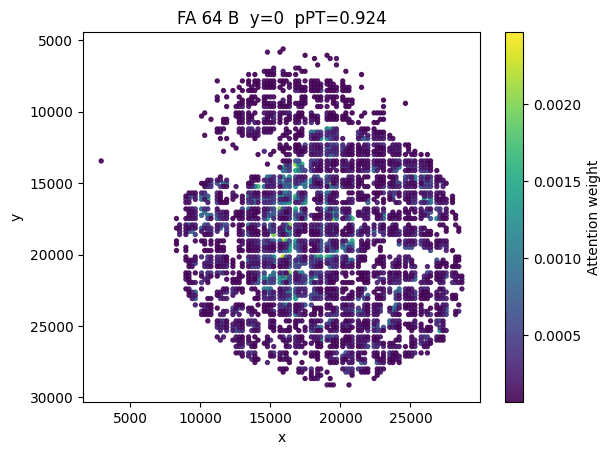

In [81]:
def plot_attention_scatter(coords, attn, title="", top_points=3000):
    coords = coords.astype(np.int32)
    attn = attn.astype(np.float32)

    # plot only top points for readability
    if len(attn) > top_points:
        idx = np.argsort(-attn)[:top_points]
        coords = coords[idx]
        attn = attn[idx]

    x = coords[:, 0]
    y = coords[:, 1]

    plt.figure()
    sc = plt.scatter(x, y, c=attn, s=8, alpha=0.9)
    plt.gca().invert_yaxis()
    plt.colorbar(sc, label="Attention weight")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

plot_attention_scatter(ex["coords"], ex["attn"],
                       title=f"{ex['slide_id']}  y={ex['y_true']}  pPT={ex['p_pt']:.3f}")


In [14]:
def top_attended_table(coords, attn, k=25):
    idx = np.argsort(-attn)[:k]
    df = pd.DataFrame({
        "rank": np.arange(1, len(idx)+1),
        "x": coords[idx, 0],
        "y": coords[idx, 1],
        "attn": attn[idx],
    })
    return df

df_top = top_attended_table(ex["coords"], ex["attn"], k=25)
df_top


NameError: name 'ex' is not defined

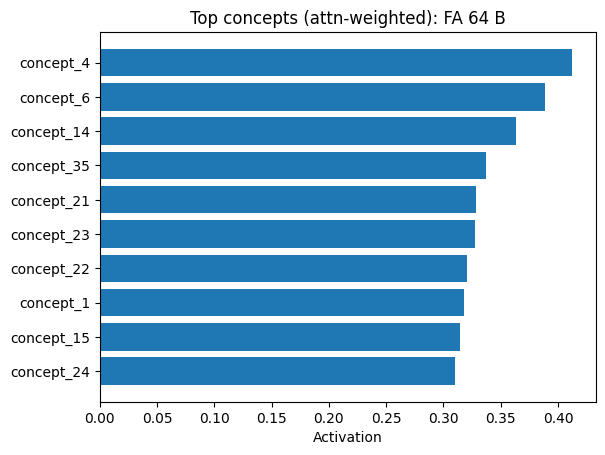

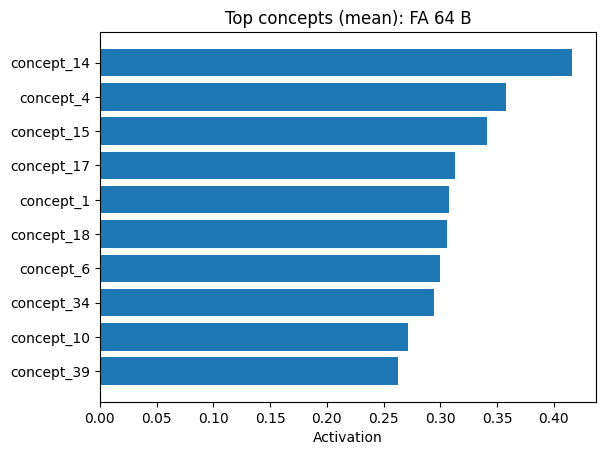

In [80]:
def plot_top_concepts(vec, concept_cols, title="", k=10, use_abs=True):
    v = vec.copy()
    order = np.argsort(-np.abs(v) if use_abs else -v)[:k] # top
    # order = np.argsort(v)[:k]  # most negative / smallest

    labels = [concept_cols[i] for i in order]
    vals = v[order]

    plt.figure()
    plt.barh(range(k), vals[::-1])
    plt.yticks(range(k), labels[::-1])
    plt.title(title)
    plt.xlabel("Activation")
    plt.show()
    

# You need concept_cols_10 in your notebook (from your CSV load)
plot_top_concepts(ex["concept_attn_weighted"], concept_cols_10,
                  title=f"Top concepts (attn-weighted): {ex['slide_id']}", k=10, use_abs=True)

plot_top_concepts(ex["concept_mean"], concept_cols_10,
                  title=f"Top concepts (mean): {ex['slide_id']}", k=10, use_abs=True)


In [10]:
def summarize_all_npz(out_dir):
    rows = []
    for p in glob.glob(os.path.join(out_dir, "*__eval.npz")):
        d = load_npz(p)
        rows.append({
            "slide_id": d["slide_id"],
            "y_true": d["y_true"],
            "p_pt": d["p_pt"],
            "n_patches": int(d["coords"].shape[0]),
            "npz_path": p,
        })
    return pd.DataFrame(rows)

OUT_DIR = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\slide_preds_2.5x"
df_sum = summarize_all_npz(OUT_DIR)
df_sum.sort_values("p_pt", ascending=False).head(50)


,slide_id,y_true,p_pt,n_patches,npz_path
137,PT 47 B1,1,0.994892,207,C:\Users\Vivian\Documents\CONCH\test_text_enco...
71,FA 64 B,0,0.994176,945,C:\Users\Vivian\Documents\CONCH\test_text_enco...
152,PT 55 B2,1,0.992332,1025,C:\Users\Vivian\Documents\CONCH\test_text_enco...
151,PT 55 B1,1,0.990121,939,C:\Users\Vivian\Documents\CONCH\test_text_enco...
197,PT 78 B2,1,0.982607,1021,C:\Users\Vivian\Documents\CONCH\test_text_enco...
214,PT 87 B1,1,0.978229,531,C:\Users\Vivian\Documents\CONCH\test_text_enco...
210,PT 85 B1,1,0.977251,334,C:\Users\Vivian\Documents\CONCH\test_text_enco...
215,PT 87 B2,1,0.974938,647,C:\Users\Vivian\Documents\CONCH\test_text_enco...
221,PT 90 B2,1,0.970309,867,C:\Users\Vivian\Documents\CONCH\test_text_enco...
188,PT 74 B1,1,0.969791,777,C:\Users\Vivian\Documents\CONCH\test_text_enco...


In [11]:
def summarize_all_npz(out_dir):
    rows = []
    for p in glob.glob(os.path.join(out_dir, "*__eval.npz")):
        d = load_npz(p)
        rows.append({
            "slide_id": d["slide_id"],
            "y_true": d["y_true"],
            "p_pt": d["p_pt"],
            "n_patches": int(d["coords"].shape[0]),
            "npz_path": p,
        })
    return pd.DataFrame(rows)

OUT_DIR = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\slide_preds_2.5x"
df_sum = summarize_all_npz(OUT_DIR)
df_sum.sort_values("p_pt", ascending=True).head(20)


,slide_id,y_true,p_pt,n_patches,npz_path
4,FA 102 B1,0,0.066936,731,C:\Users\Vivian\Documents\CONCH\test_text_enco...
184,PT 71 B2,1,0.076739,821,C:\Users\Vivian\Documents\CONCH\test_text_enco...
11,FA 105 B2,0,0.080718,990,C:\Users\Vivian\Documents\CONCH\test_text_enco...
153,PT 56 B1,1,0.083226,707,C:\Users\Vivian\Documents\CONCH\test_text_enco...
127,PT 41 B,1,0.083880,311,C:\Users\Vivian\Documents\CONCH\test_text_enco...
182,PT 70 B2,1,0.087385,515,C:\Users\Vivian\Documents\CONCH\test_text_enco...
54,FA 130 B1,0,0.091294,771,C:\Users\Vivian\Documents\CONCH\test_text_enco...
5,FA 102 B2,0,0.091945,399,C:\Users\Vivian\Documents\CONCH\test_text_enco...
154,PT 56 B2,1,0.092169,823,C:\Users\Vivian\Documents\CONCH\test_text_enco...
181,PT 70 B1,1,0.092991,664,C:\Users\Vivian\Documents\CONCH\test_text_enco...


vis patches for top concepts

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def read_patch_map_csv(patch_map_csv):
    df = pd.read_csv(patch_map_csv)
    df.columns = [c.strip().lower() for c in df.columns]
    # normalize column names
    if "patch_file" not in df.columns:
        df = df.rename(columns={df.columns[0]: "patch_file"})
    if "x" not in df.columns or "y" not in df.columns:
        raise ValueError(f"patch_map.csv must have x,y columns: {patch_map_csv}")
    df["patch_file"] = df["patch_file"].astype(str)
    df["x"] = pd.to_numeric(df["x"], errors="coerce").astype("Int64")
    df["y"] = pd.to_numeric(df["y"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["x","y"])
    df["x"] = df["x"].astype(int)
    df["y"] = df["y"].astype(int)
    return df

def build_coord_to_patchfile(df_map):
    # exact match (x,y) -> patch_file
    return {(int(r.x), int(r.y)): r.patch_file for r in df_map.itertuples(index=False)}

def npy_to_rgb(arr):
    # accepts HxWx3 or 3xHxW, uint8 or float
    if arr.ndim != 3:
        raise ValueError(f"Expected 3D array, got {arr.shape}")
    if arr.shape[0] in (3,4) and arr.shape[-1] not in (3,4):
        arr = arr[:3].transpose(1,2,0)
    elif arr.shape[-1] in (3,4):
        arr = arr[..., :3]
    else:
        raise ValueError(f"Cannot infer channels from shape {arr.shape}")

    if arr.dtype != np.uint8:
        arr = arr.astype(np.float32)
        if arr.max() <= 1.5:
            arr = arr * 255.0
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    return arr


In [94]:
def show_top_attention_patches(npz_dict, patch_root, k=9, ncols=3, title=None):
    sid = npz_dict["slide_id"]
    coords = npz_dict["coords"]
    attn = npz_dict["attn"]

    # slide folder + patch_map.csv
    slide_dir = os.path.join(patch_root, sid)
    patch_map_csv = os.path.join(slide_dir, "patch_map.csv")
    if not os.path.isfile(patch_map_csv):
        raise FileNotFoundError(patch_map_csv)

    df_map = read_patch_map_csv(patch_map_csv)
    coord2file = build_coord_to_patchfile(df_map)

    idx = np.argsort(-attn)[:k]

    Xc = npz_dict["Xc"]

    for i in idx:
        concept_vec = Xc[i]

        # attention-weighted contribution
        contrib = concept_vec * attn[i]

        # now compute top index
        top_idx = contrib.argmax()

        # now you can use it
        top_name = concept_cols_10[top_idx]
        top_score = concept_vec[top_idx]


    chosen = [(int(coords[i,0]), int(coords[i,1]), float(attn[i])) for i in idx]

    imgs = []
    captions = []
    for (x,y,w) in chosen:
        fname = coord2file.get((x,y))
        if fname is None:
            # if exact match fails, you can later switch to nearest-neighbor
            imgs.append(None)
            captions.append(f"(missing)\n({x},{y})\nw={w:.3f}")
            continue
        p = os.path.join(slide_dir, fname)
        if not os.path.isfile(p):
            imgs.append(None)
            captions.append(f"(missing file)\n{fname}\n({x},{y})\nw={w:.3f}")
            continue

        arr = np.load(p)
        rgb = npy_to_rgb(arr)
        imgs.append(rgb)
        # captions.append(f"{fname}\n({x},{y})\nw={w:.3f}")
        captions.append(
        f"{fname}\n({x},{y})\n"
        f"Attn={w:.3f}\n"
        f"Top concept: {top_name} ({top_score:.2f})"
    )


    n = len(imgs)
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(4*ncols, 4*nrows))
    for i in range(n):
        ax = plt.subplot(nrows, ncols, i+1)
        if imgs[i] is None:
            ax.text(0.5, 0.5, "NOT FOUND", ha="center", va="center")
            ax.set_axis_off()
        else:
            ax.imshow(imgs[i])
            ax.set_axis_off()
        ax.set_title(captions[i], fontsize=8)
    if title is None:
        title = f"{sid}  y={npz_dict['y_true']}  pPT={npz_dict['p_pt']:.3f}"
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


In [96]:
def top_coords_for_concept(coords, Xc, concept_idx, k=9):
    scores = Xc[:, concept_idx]
    idx = np.argsort(-scores)[:k]   # highest scores
    return coords[idx], scores[idx]

concept_idx = 4  # e.g. concept_12
coords_top, scores_top = top_coords_for_concept(ex["coords"], ex["Xc"], concept_idx, k=9)

print("Concept:", concept_cols_10[concept_idx])
print(list(zip(coords_top[:,0], coords_top[:,1], scores_top)))

def show_patches_for_coords(slide_id, coords_top, scores_top, PATCH_ROOT, ncols=3, title=""):
    slide_dir = os.path.join(PATCH_ROOT, slide_id)
    patch_map_csv = os.path.join(slide_dir, "patch_map.csv")
    dfm = read_patch_map_csv(patch_map_csv)

    coord2file = {(int(r.x), int(r.y)): r.patch_file for r in dfm.itertuples(index=False)}

    k = len(scores_top)
    nrows = int(np.ceil(k / ncols))
    plt.figure(figsize=(4*ncols, 4*nrows))

    for i in range(k):
        x, y = int(coords_top[i,0]), int(coords_top[i,1])
        sc = float(scores_top[i])
        ax = plt.subplot(nrows, ncols, i+1)

        fname = coord2file.get((x,y))
        if fname is None:
            ax.text(0.5, 0.5, "NOT FOUND", ha="center", va="center")
            ax.set_axis_off()
            ax.set_title(f"({x},{y})\nscore={sc:.3f}", fontsize=8)
            continue

        p = os.path.join(slide_dir, fname)
        arr = np.load(p)
        ax.imshow(npy_to_rgb(arr))
        ax.set_axis_off()
        ax.set_title(f"{fname}\n({x},{y})\nscore={sc:.3f}", fontsize=8)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

Concept: concept_4
[(23520, 21728, 0.749467), (27104, 19264, 0.74214894), (26208, 15232, 0.7401589), (13440, 16128, 0.7230499), (18144, 20608, 0.7210959), (23968, 21728, 0.7185557), (13440, 24640, 0.7168935), (16352, 20160, 0.71615374), (17472, 21952, 0.71258247)]


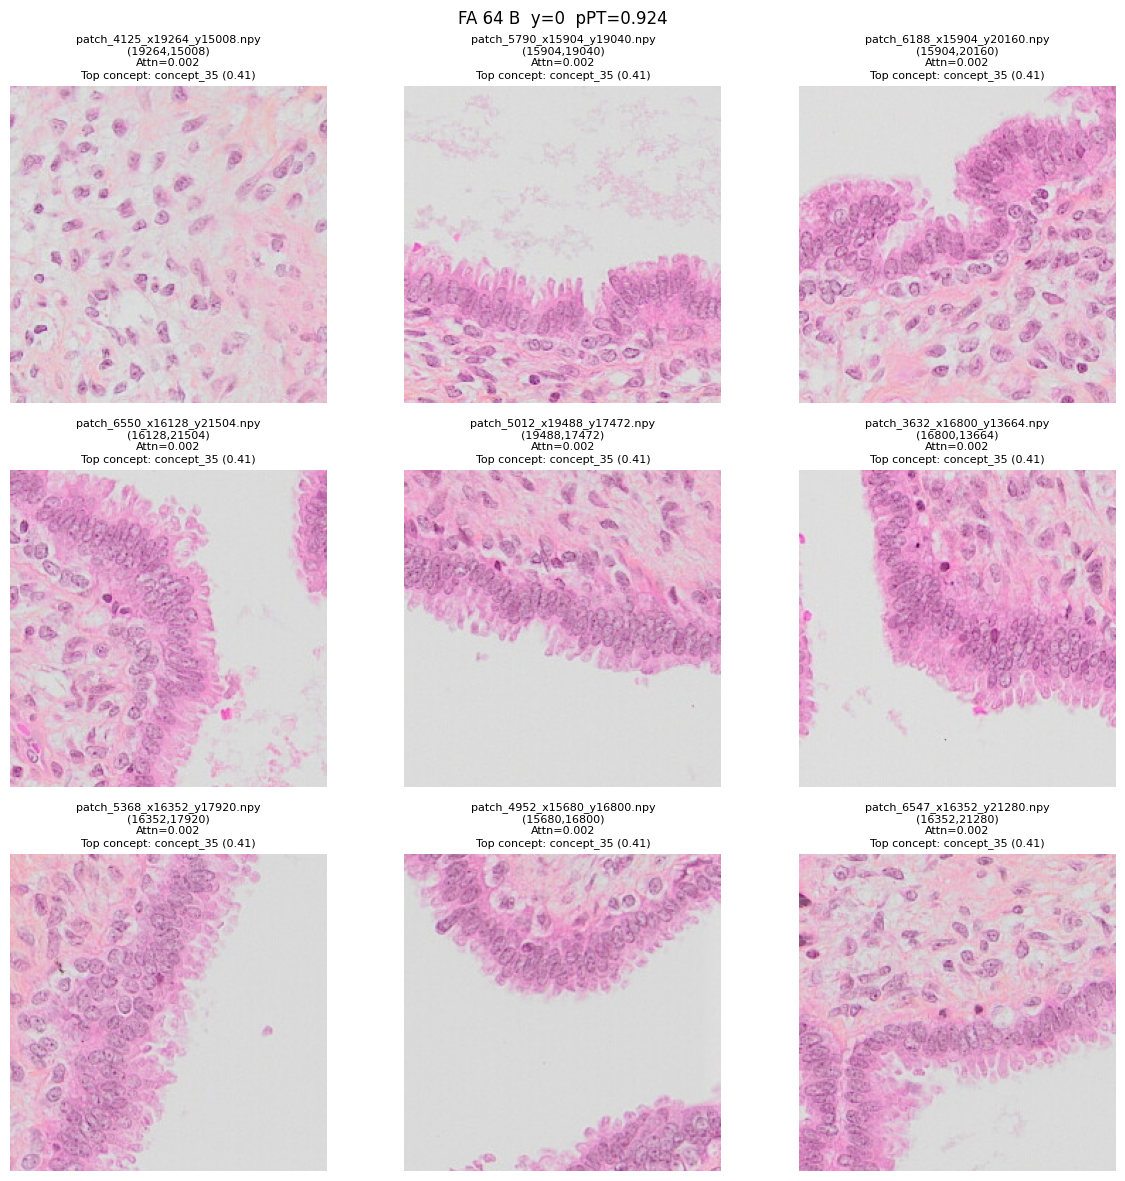

In [98]:
# ex = load_npz(path_to_one_npz)
PATCH_ROOT = r"C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\FA"  # contains per-slide subfolders
show_top_attention_patches(ex, PATCH_ROOT, k=9, ncols=3)

# sid = ex["slide_id"]
# show_patches_for_coords(
#     sid, coords_top, scores_top, PATCH_ROOT,
#     title=f"Top patches for {concept_cols_10[concept_idx]} — {sid}"
# )


In [26]:
# SAVE PRED
df_all = pd.concat(all_preds, ignore_index=True)

df_all["y_pred"] = (df_all["p_pt"] >= 0.5).astype(int)
df_all["correct"] = (df_all["y_pred"] == df_all["y_true"])
df_all["conf"] = (df_all["p_pt"] - 0.5).abs()

# pick 4 slides (out-of-fold)
best_fa  = df_all[(df_all.y_true==0) & (df_all.correct)].sort_values("p_pt", ascending=True).iloc[0]
best_pt  = df_all[(df_all.y_true==1) & (df_all.correct)].sort_values("p_pt", ascending=False).iloc[0]
worst_fa = df_all[(df_all.y_true==0) & (~df_all.correct)].sort_values("p_pt", ascending=False).iloc[0]
worst_pt = df_all[(df_all.y_true==1) & (~df_all.correct)].sort_values("p_pt", ascending=True).iloc[0]

picked = pd.DataFrame([best_fa, best_pt, worst_fa, worst_pt])
print("\n==================== BEST/WORST SLIDES (OUT-OF-FOLD) ====================")
print(picked[["slide_id","fold","y_true","p_pt","y_pred","correct","conf"]].to_string(index=False))



==================== BEST/WORST SLIDES (OUT-OF-FOLD) ====================
 slide_id      fold  y_true     p_pt  y_pred  correct     conf
FA 102 B2 FA_PT_k=2       0 0.027906       0     True 0.472094
 PT 49 B1 FA_PT_k=3       1 0.971571       1     True 0.471571
  FA 64 B FA_PT_k=0       0 0.956610       1    False 0.456610
 PT 70 B2 FA_PT_k=4       1 0.062279       0    False 0.437721


In [26]:
# load a npz file and show top attention patches
import os
import numpy as np

npz_path = r'C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\slide_preds\PT 78 B2__eval.npz'
npz_dict = load_npz(npz_path)
PATCH_ROOT = r"C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\40x\PT"

# show_top_attention_patches(npz_dict, PATCH_ROOT, k=9, ncols=3)
# print keys of npz_dict to see what you have available for analysis
print(npz_dict.keys())
npz_dict['p_pt']

dict_keys(['slide_id', 'y_true', 'p_pt', 'coords', 'Xc', 'attn', 'concept_mean', 'concept_attn_weighted'])


0.8390781283378601

volcano plots

In [12]:
import os, glob, numpy as np, pandas as pd
from scipy.stats import ttest_ind

NPZ_DIR = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\slide_preds_2.5x"
KEY = 'concept_attn_weighted' #"concept_attn_weighted"  # or "concept_mean"
EPS = 1e-6

files = sorted(glob.glob(os.path.join(NPZ_DIR, "*.npz")))
Y, S = [], []
for f in files:
    d = np.load(f, allow_pickle=True)
    Y.append(int(d["y_true"]))
    S.append(np.asarray(d[KEY], dtype=float))
Y = np.asarray(Y); S = np.vstack(S)   # [n_slides, n_concepts]

fa, pt = S[Y==0], S[Y==1]
mean_fa, mean_pt = fa.mean(0), pt.mean(0)
log2fc = np.log2((mean_pt + EPS) / (mean_fa + EPS))
pvals = np.array([ttest_ind(pt[:,i], fa[:,i], equal_var=False, nan_policy="omit").pvalue for i in range(S.shape[1])])
df = pd.DataFrame({"concept_idx": np.arange(S.shape[1]), "mean_FA": mean_fa, "mean_PT": mean_pt,
                   "log2FC_PT_vs_FA": log2fc, "p": pvals, "neglog10p": -np.log10(np.maximum(pvals, 1e-300))})
df.to_csv(r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\2.5x_concept_attn_weighted_volcano_table.csv", index=False)
print(df.sort_values("neglog10p", ascending=False).head(50))

    concept_idx   mean_FA   mean_PT  log2FC_PT_vs_FA             p  neglog10p
40           40 -0.000921  0.083198              NaN  6.614738e-17  16.179487
27           27  0.068910  0.152783         1.148691  3.520255e-16  15.453426
35           35  0.169997  0.276041         0.699372  1.161442e-15  14.935003
4             4  0.248116  0.320624         0.369867  1.241397e-15  14.906089
22           22  0.125661  0.216222         0.782971  1.789684e-15  14.747224
21           21  0.103017  0.172971         0.747644  3.057783e-15  14.514593
36           36  0.084281  0.177885         1.077649  4.745395e-15  14.323728
13           13  0.237364  0.308152         0.376544  6.436194e-15  14.191371
46           46  0.255741  0.192015        -0.413464  1.119861e-14  13.950836
23           23  0.028547  0.073418         1.362738  3.704133e-14  13.431313
2             2 -0.001464  0.064899              NaN  5.338925e-14  13.272546
45           45  0.183420  0.124848        -0.554976  7.612222e-

C:\Users\Vivian\AppData\Local\Temp\ipykernel_37792\3529186489.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y.append(int(d["y_true"]))
C:\Users\Vivian\AppData\Local\Temp\ipykernel_37792\3529186489.py:18: RuntimeWarning: invalid value encountered in log2
  log2fc = np.log2((mean_pt + EPS) / (mean_fa + EPS))


In [14]:
import os, glob, numpy as np, pandas as pd
from scipy.stats import ttest_ind

def compute_volcano(npz_dir, key):
    files = sorted(glob.glob(os.path.join(npz_dir, "*.npz")))

    Y, S = [], []
    for f in files:
        d = np.load(f, allow_pickle=True)
        Y.append(int(d["y_true"]))
        S.append(np.asarray(d[key], dtype=float))

    Y = np.asarray(Y)
    S = np.vstack(S)

    fa = S[Y==0]
    pt = S[Y==1]

    mean_fa = fa.mean(0)
    mean_pt = pt.mean(0)

    diff = mean_pt - mean_fa

    pvals = np.array([
        ttest_ind(pt[:,i], fa[:,i], equal_var=False).pvalue
        for i in range(S.shape[1])
    ])

    df = pd.DataFrame({
        "concept_idx": np.arange(S.shape[1]),
        "mean_FA": mean_fa,
        "mean_PT": mean_pt,
        "diff": diff,
        "p": pvals,
        "neglog10p": -np.log10(np.maximum(pvals, 1e-300))
    })

    return df

In [29]:
NPZ_DIR = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\slide_preds"

df_mean = compute_volcano(NPZ_DIR, "concept_mean")
df_attn = compute_volcano(NPZ_DIR, "concept_attn_weighted")

C:\Users\Vivian\AppData\Local\Temp\ipykernel_37792\1853535758.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y.append(int(d["y_true"]))


<Figure size 700x600 with 0 Axes>

Text(0.4644395015486185, 20.274581020296136, '40')

Text(0.2201383125105571, 18.454700770688977, '4')

Text(0.22589318867547703, 18.132815391285803, '24')

Text(0.29841310548689504, 15.32819751731163, '27')

...

Text(-0.056658977488095695, 2.1696546296323054, '44')

Text(-0.07275986979061272, 1.844604435019626, '41')

Text(0.5, 0, 'log2(mean_PT / mean_FA)')

Text(0, 0.5, '-log10(p-value)')

Text(0.5, 1.0, 'Volcano Plot (Concept Attention-Weighted)')

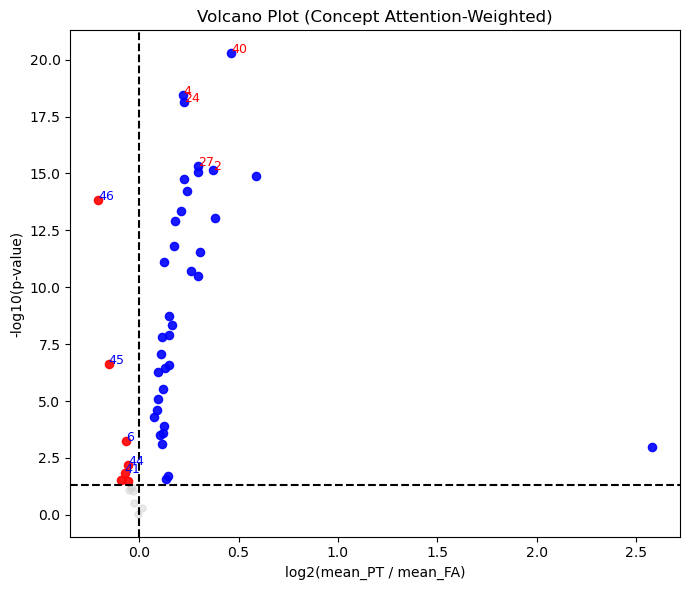

In [30]:
import numpy as np
import matplotlib.pyplot as plt

p_thresh = 0.05
eps = 1e-3   # small stabilizer for near-zero values

df = df_attn.copy()

mPT = df["mean_PT"].to_numpy(float)
mFA = df["mean_FA"].to_numpy(float)

# --- Shift if necessary (to avoid log of negative numbers) ---
min_val = min(mPT.min(), mFA.min())
shift = (-min_val + eps) if min_val <= 0 else 0.0

log2fc = np.log2((mPT + shift + eps) / (mFA + shift + eps))
neglog10p = -np.log10(np.maximum(df["p"].to_numpy(float), 1e-300))

df["log2FC"] = log2fc
df["neglog10p"] = neglog10p

sig_line = -np.log10(p_thresh)
is_sig = df["neglog10p"] >= sig_line


plt.figure(figsize=(7,6))

# LABELED VERSION
# Top 3 PT-enriched (largest positive log2FC + significant)
top_pt = df[(df["log2FC"] > 0) & (df["neglog10p"] >= sig_line)] \
            .sort_values("neglog10p", ascending=False) \
            .head(5)

# Top 3 FA-enriched (largest negative log2FC + significant)
top_fa = df[(df["log2FC"] < 0) & (df["neglog10p"] >= sig_line)] \
            .sort_values("neglog10p", ascending=False) \
            .head(5)

# Label PT concepts
for _, row in top_pt.iterrows():
    plt.text(row["log2FC"],
             row["neglog10p"],
             str(int(row["concept_idx"])),
             fontsize=9,
             color="red")

# Label FA concepts
for _, row in top_fa.iterrows():
    plt.text(row["log2FC"],
             row["neglog10p"],
             str(int(row["concept_idx"])),
             fontsize=9,
             color="blue")
# LABELED 

# Non-significant
plt.scatter(df.loc[~is_sig, "log2FC"],
            df.loc[~is_sig, "neglog10p"],
            color="lightgrey",
            alpha=0.5,
            s=25)

# Significant PT-enriched
plt.scatter(df.loc[is_sig & (df["log2FC"] > 0), "log2FC"],
            df.loc[is_sig & (df["log2FC"] > 0), "neglog10p"],
            color="blue",
            alpha=0.9,
            s=35)

# Significant FA-enriched
plt.scatter(df.loc[is_sig & (df["log2FC"] < 0), "log2FC"],
            df.loc[is_sig & (df["log2FC"] < 0), "neglog10p"],
            color="red",
            alpha=0.9,
            s=35)

plt.axhline(sig_line, linestyle="--", color="black")
plt.axvline(0, linestyle="--", color="black")

plt.xlabel("log2(mean_PT / mean_FA)")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot (Concept Attention-Weighted)")
plt.tight_layout()
plt.show()

In [10]:
df.loc[df["log2FC"].abs().idxmax(), ["concept_idx","mean_FA","mean_PT","log2FC","p","neglog10p"]]

concept_idx    9.000000e+00
mean_FA       -3.996051e-02
mean_PT        1.107638e-02
log2FC        -1.762045e+00
p              1.298330e-15
neglog10p      1.488661e+01
Name: 9, dtype: float64

In [120]:
df_mean.sort_values("neglog10p", ascending=False).head(50)

,concept_idx,mean_FA,mean_PT,diff,p,neglog10p
40,40,0.032440,0.089466,0.057026,1.285203e-18,17.891028
24,24,0.205004,0.252149,0.047145,5.929954e-15,14.226949
27,27,0.084505,0.134591,0.050086,2.610817e-14,13.583224
23,23,0.194484,0.237392,0.042908,4.570791e-14,13.340009
4,4,0.310306,0.363764,0.053457,8.959014e-14,13.047740
35,35,0.130808,0.186864,0.056056,9.629696e-13,12.016387
9,9,-0.058136,-0.024048,0.034087,6.047965e-12,11.218391
21,21,0.204060,0.251785,0.047725,1.118250e-11,10.951461
22,22,0.176762,0.220694,0.043932,3.728674e-11,10.428446
36,36,0.046988,0.102062,0.055074,5.193206e-11,10.284564


In [ ]:
df_attn.sort_values("neglog10p", ascending=False).head(50)

,concept_idx,mean_FA,mean_PT,diff,p,neglog10p
40,40,0.075059,0.157227,0.082168,5.313969e-21,20.274581
4,4,0.352763,0.434206,0.081444,3.509936e-19,18.454701
24,24,0.262887,0.331397,0.068510,7.365201e-19,18.132815
27,27,0.125623,0.186959,0.061336,4.696804e-16,15.328198
2,2,0.080210,0.145579,0.065369,6.904774e-16,15.160851
35,35,0.193384,0.269374,0.075990,8.569350e-16,15.067052
9,9,-0.039961,0.011076,0.051037,1.298330e-15,14.886615
22,22,0.232030,0.294584,0.062554,1.760628e-15,14.754332
34,34,0.272850,0.347694,0.074844,6.213493e-15,14.206664
46,46,0.249372,0.197093,-0.052278,1.491026e-14,13.826515


: 

In [31]:
df_compare = df_mean.merge(
    df_attn,
    on="concept_idx",
    suffixes=("_mean", "_attn")
)

df_compare["percent_gain"] = (
    (np.abs(df_compare["diff_attn"]) - np.abs(df_compare["diff_mean"]))
    / (np.abs(df_compare["diff_mean"]) + 1e-6)
) * 100

print("Average % gain:", df_compare["percent_gain"].mean())
print("Median % gain:", df_compare["percent_gain"].median())

Average % gain: 42.445314850759516
Median % gain: 39.03443189482074


<Figure size 700x600 with 0 Axes>

Text(0.0821684174457703, 20.274581020296136, '40')

Text(0.0814435752727678, 18.454700770688977, '4')

Text(0.0759899803812499, 15.06705212464173, '35')

Text(0.07578055396268517, 13.043973908312504, '36')

...

Text(-0.017115464436485484, 2.1696546296323054, '44')

Text(-0.01613371080997511, 1.844604435019626, '41')

Text(0.5, 0, 'Mean(PT) - Mean(FA)')

Text(0, 0.5, '-log10(p)')

Text(0.5, 1.0, 'Concept Volcano: Mean vs Attention')

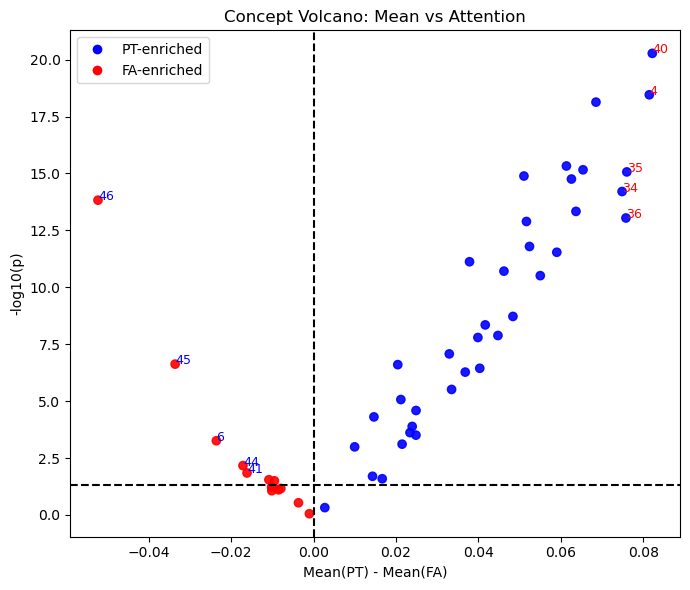

In [33]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,6))

# Baseline (mean)
# plt.scatter(df_mean["diff"],
#             df_mean["neglog10p"],
#             color="grey",
#             alpha=0.4,
#             label="Concept Mean")

# Attention (colored)
colors = np.where(df_attn["diff"] > 0,  "blue","red")

plt.scatter(df_attn["diff"],
            df_attn["neglog10p"],
            c=colors,
            alpha=0.9,
            label="Attention-Weighted")

plt.axvline(0, linestyle="--", color="black")
plt.axhline(-np.log10(0.05), linestyle="--", color="black")

# # Label top 5 attention concepts
# top5 = df_attn.sort_values("neglog10p", ascending=False).head(5)


# for _, row in top5.iterrows():
#     plt.text(row["diff"],
#              row["neglog10p"],
#              str(int(row["concept_idx"])),
#              fontsize=9)
    
# Top 5 PT-enriched (largest positive diff)
top_pt = df_attn.sort_values("diff", ascending=False).head(5)

# Top 5 FA-enriched (largest negative diff)
top_fa = df_attn.sort_values("diff", ascending=True).head(5)

# Label PT concepts
for _, row in top_pt.iterrows():
    plt.text(row["diff"],
             row["neglog10p"],
             str(int(row["concept_idx"])),
             fontsize=9,
             color="red")

# Label FA concepts
for _, row in top_fa.iterrows():
    plt.text(row["diff"],
             row["neglog10p"],
             str(int(row["concept_idx"])),
             fontsize=9,
             color="blue")

from matplotlib.lines import Line2D

legend_elems = [
    # Line2D([0],[0], marker='o', color='w', label='Concept Mean', markerfacecolor='grey', markersize=8, alpha=0.4),
    Line2D([0],[0], marker='o', color='w', label='PT-enriched', markerfacecolor='blue', markersize=8),
    Line2D([0],[0], marker='o', color='w', label='FA-enriched', markerfacecolor='red', markersize=8),
]

plt.legend(handles=legend_elems, loc="upper left")
plt.xlabel("Mean(PT) - Mean(FA)")
plt.ylabel("-log10(p)")
plt.title("Concept Volcano: Mean vs Attention")
# plt.legend()
plt.tight_layout()
plt.show()

stats on slide concepts scores

In [27]:
# ==========================================
# Fast stats for volcano CSVs (per scale)
# 1) Benjamini–Hochberg FDR correction
# 2) Count significant PT/FA concepts by magnification group (LOW/MEDIUM/HIGH)
# 3) Optional: group-level separation test across magnification groups
# ==========================================

import os
import numpy as np
import pandas as pd

# ---------- CONFIG ----------
# Provide one CSV per scale (your volcano-summary CSVs)
SCALE2CSV = {
    "2.5x": r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\2.5x_concept_attn_weighted_volcano_table.csv",
    "5x":   r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\5x_concept_attn_weighted_volcano_table.csv",
    "10x":  r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\10x_concept_attn_volcano_table.csv",
}

# Pathologist-defined magnification visibility groups for each concept_idx
# (edit these sets if your indices differ)
LOW_MAG = {
    7,8,31,26,27,29,30,14,15,16,17,0,5,6,1,10,11,12,41,42,43,44,45,46,47,48,49
}
MED_MAG = {2,3,4,9,13,18,19,20,21,22,23,24,25,28}
HIGH_MAG = {39,40,32,33,34,35,36,37,38}

FDR_Q = 0.05  # significance threshold after FDR correction


# ---------- HELPERS ----------
def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    """
    Benjamini–Hochberg FDR correction.
    Returns q-values aligned to the original order.
    """
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / (np.arange(1, n + 1))
    # enforce monotonicity from largest to smallest
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)
    out = np.empty_like(q)
    out[order] = q
    return out


def concept_group(concept_idx: int) -> str:
    if concept_idx in LOW_MAG:
        return "LOW"
    if concept_idx in MED_MAG:
        return "MEDIUM"
    if concept_idx in HIGH_MAG:
        return "HIGH"
    return "UNKNOWN"


def safe_effect(row) -> float:
    """
    Prefer log2FC if present/finite; otherwise fall back to mean difference (PT - FA).
    This avoids undefined log2FC when mean_FA <= 0.
    """
    fc = row.get("log2FC_PT_vs_FA", np.nan)
    try:
        fc = float(fc)
    except Exception:
        fc = np.nan
    if np.isfinite(fc):
        return fc
    # fallback
    return float(row["mean_PT"]) - float(row["mean_FA"])


def load_and_process(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    # Ensure required columns exist
    required = ["concept_idx", "mean_FA", "mean_PT", "p"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {csv_path}: {missing}")

    # Clean
    df["concept_idx"] = df["concept_idx"].astype(int)
    df["p"] = pd.to_numeric(df["p"], errors="coerce")
    df = df.dropna(subset=["p"]).copy()

    # Add group + direction + effect
    df["mag_group"] = df["concept_idx"].apply(concept_group)
    df["effect"] = df.apply(safe_effect, axis=1)  # log2FC if valid else PT-FA
    df["direction"] = np.where(df["mean_PT"] > df["mean_FA"], "PT", "FA")

    # FDR correction
    df["q_bh"] = bh_fdr(df["p"].values)
    df["sig_fdr"] = df["q_bh"] < FDR_Q

    return df


def summarize_scale(df: pd.DataFrame, scale_name: str) -> dict:
    sig = df[df["sig_fdr"]].copy()

    # Count PT/FA significant concepts by magnification group
    counts = (
        sig.groupby(["direction", "mag_group"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=["PT", "FA"], fill_value=0)
    )

    # Also: total significant PT/FA
    totals = sig["direction"].value_counts().reindex(["PT", "FA"], fill_value=0)

    # Top concepts (by q-value) per direction
    top_pt = sig[sig["direction"] == "PT"].sort_values("q_bh").head(5)
    top_fa = sig[sig["direction"] == "FA"].sort_values("q_bh").head(5)

    out = {
        "scale": scale_name,
        "n_concepts": len(df),
        "n_sig_total": int(sig.shape[0]),
        "n_sig_PT": int(totals["PT"]),
        "n_sig_FA": int(totals["FA"]),
        "counts_table": counts,
        "top_PT": top_pt[["concept_idx", "mag_group", "mean_FA", "mean_PT", "effect", "p", "q_bh"]],
        "top_FA": top_fa[["concept_idx", "mag_group", "mean_FA", "mean_PT", "effect", "p", "q_bh"]],
    }
    return out


# ---------- RUN ----------
all_processed = {}
summaries = []

for scale, path in SCALE2CSV.items():
    if not os.path.isfile(path):
        raise FileNotFoundError(path)

    df = load_and_process(path)
    all_processed[scale] = df

    summ = summarize_scale(df, scale)
    summaries.append(summ)

    # Save an updated CSV with q-values + group labels
    out_csv = os.path.splitext(path)[0] + f"_FDRq{FDR_Q}.csv"
    df.to_csv(out_csv, index=False)
    print(f"[{scale}] wrote: {out_csv} | n={summ['n_concepts']} sig(FDR<{FDR_Q})={summ['n_sig_total']}")

print("\n==================== SUMMARY ====================")
for s in summaries:
    print(f"\n--- {s['scale']} ---")
    print(f"Total concepts: {s['n_concepts']}")
    print(f"Significant (FDR<{FDR_Q}): {s['n_sig_total']} | PT: {s['n_sig_PT']} | FA: {s['n_sig_FA']}")
    print("\nSignificant counts by direction x magnification group:")
    print(s["counts_table"])

    if s["n_sig_PT"] > 0:
        print("\nTop PT-enriched concepts (lowest q):")
        print(s["top_PT"].to_string(index=False))
    if s["n_sig_FA"] > 0:
        print("\nTop FA-enriched concepts (lowest q):")
        print(s["top_FA"].to_string(index=False))


# ---------- OPTIONAL: quick one-line statements you can paste into the paper ----------
# Example: "At 10×, X/Y significant PT-enriched concepts were high-magnification."
for s in summaries:
    counts = s["counts_table"]
    pt_total = s["n_sig_PT"]
    if pt_total > 0:
        high_pt = int(counts.loc["PT"].get("HIGH", 0))
        print(f"\nSentence ({s['scale']}): Among FDR-significant PT-enriched concepts, "
              f"{high_pt}/{pt_total} belonged to the high-magnification group.")

[2.5x] wrote: C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\2.5x_concept_attn_weighted_volcano_table_FDRq0.05.csv | n=50 sig(FDR<0.05)=41
[5x] wrote: C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\5x_concept_attn_weighted_volcano_table_FDRq0.05.csv | n=50 sig(FDR<0.05)=41
[10x] wrote: C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\10x_concept_attn_volcano_table_FDRq0.05.csv | n=50 sig(FDR<0.05)=43

==================== SUMMARY ====================

--- 2.5x ---
Total concepts: 50
Significant (FDR<0.05): 41 | PT: 35 | FA: 6

Significant counts by direction x magnification group:
mag_group  HIGH  LOW  MEDIUM
direction                   
PT            8   15      12
FA            0    6       0

Top PT-enriched concepts (lowest q):
 concept_idx mag_group   mean_FA  mean_PT   effect            p         q_bh
          40      HIGH -0.000921 0.083198 0.084119 6.614738e-17 3.307369e-15
          27       LOW  0.068910 0.152783 1.148691 3.52

In [ ]:
# ==========================================
# Scatter + Spearman correlation of concept effects between scales
# - Reads your per-scale volcano CSVs
# - Uses log2FC_PT_vs_FA when valid, otherwise uses (mean_PT - mean_FA)
# - Makes:
#   (1) pairwise scatter plots (2.5x vs 5x, 2.5x vs 10x, 5x vs 10x)
#   (2) a small correlation table (Spearman rho, p-value, n)
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ---------- CONFIG ----------
# SCALE2CSV = {
#     "2.5x": r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\2.5x_concept_attn_weighted_volcano_table.csv",
#     "5x":   r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\5x_concept_attn_weighted_volcano_table.csv",
#     "10x":  r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\10x_concept_attn_volcano_table.csv",
# }

SCALE2CSV = {
    "2.5x": r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\2p5x_norm_v2_RR\RR_2p5x_concept_attn_weighted_statistics.csv",
    "5x":   r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\5x_norm_v2_RR\RR_5x_concept_attn_weighted_statistics.csv",
    "10x":  r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\10x_norm_v2_RR\RR_10x_concept_attn_weighted_statistics.csv",
}
# If True, only include concepts significant in BOTH scales being compared (after FDR)
# If False, include all concepts with finite effects in both.
ONLY_SHARED_SIGNIFICANT = False
FDR_Q = 0.05

# Save figures here (set to None to just show)
OUTDIR = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\data_v2"  # e.g., r"C:\Users\Vivian\Documents\figures"
os.makedirs(OUTDIR, exist_ok=True)


# ---------- HELPERS ----------
def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / (np.arange(1, n + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)
    out = np.empty_like(q)
    out[order] = q
    return out

def load_volcano(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    required = ["concept_idx", "mean_FA", "mean_PT", "p"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {csv_path}: {missing}")

    df = df.copy()
    df["concept_idx"] = df["concept_idx"].astype(int)
    df["p"] = pd.to_numeric(df["p"], errors="coerce")
    df = df.dropna(subset=["p"])

    # Effect: prefer log2FC when finite, else fallback to PT - FA
    # if "log2FC_PT_vs_FA" in df.columns:
    #     df["log2FC_PT_vs_FA"] = pd.to_numeric(df["log2FC_PT_vs_FA"], errors="coerce")
    # else:
    #     df["log2FC_PT_vs_FA"] = np.nan

    # data v2
    if "log2FC" in df.columns:
        df["log2FC"] = pd.to_numeric(df["log2FC"], errors="coerce")
    else:
        df["log2FC"] = np.nan

    df["effect"] = df["log2FC"]
    fallback = (df["mean_PT"].astype(float) - df["mean_FA"].astype(float))
    df.loc[~np.isfinite(df["effect"].values), "effect"] = fallback.loc[~np.isfinite(df["effect"].values)]

    # FDR
    df["q_bh"] = bh_fdr(df["p"].values)
    df["sig_fdr"] = df["q_bh"] < FDR_Q

    # Keep only needed
    return df[["concept_idx", "mean_FA", "mean_PT", "effect", "p", "q_bh", "sig_fdr"]].copy()

def merge_two(df_a: pd.DataFrame, df_b: pd.DataFrame, name_a: str, name_b: str) -> pd.DataFrame:
    m = df_a.merge(df_b, on="concept_idx", suffixes=(f"_{name_a}", f"_{name_b}"))
    # Filter finite effects
    m = m[np.isfinite(m[f"effect_{name_a}"]) & np.isfinite(m[f"effect_{name_b}"])].copy()

    if ONLY_SHARED_SIGNIFICANT:
        m = m[(m[f"sig_fdr_{name_a}"]) & (m[f"sig_fdr_{name_b}"])].copy()

    return m

def plot_scatter(m: pd.DataFrame, name_a: str, name_b: str, outpath: str | None = None):
    x = m[f"effect_{name_a}"].values
    y = m[f"effect_{name_b}"].values

    rho, pval = spearmanr(x, y)

    plt.figure(figsize=(5.5, 5.0))
    plt.scatter(x, y, s=18)
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.xlabel(f"Effect ({name_a})  [log2FC if valid else PT–FA]")
    plt.ylabel(f"Effect ({name_b})  [log2FC if valid else PT–FA]")
    plt.title(f"{name_a} vs {name_b}  |  Spearman ρ={rho:.3f}, p={pval:.2e}, n={len(m)}")

    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, dpi=300)
        plt.close()
    else:
        plt.show()

    return rho, pval, len(m)


# ---------- LOAD ----------
dfs = {}
for scale, path in SCALE2CSV.items():
    if not os.path.isfile(path):
        raise FileNotFoundError(path)
    dfs[scale] = load_volcano(path)

# ---------- PAIRWISE PLOTS + CORR TABLE ----------
pairs = [("2.5x", "5x"), ("2.5x", "10x"), ("5x", "10x")]
rows = []

for a, b in pairs:
    m = merge_two(dfs[a], dfs[b], a, b)
    fig_name = f"concept_effect_scatter_{a}_vs_{b}"
    if ONLY_SHARED_SIGNIFICANT:
        fig_name += f"_sharedSig_q{FDR_Q}"
    fig_path = os.path.join(OUTDIR, fig_name + ".png")

    rho, pval, n = plot_scatter(m, a, b, outpath=fig_path)
    rows.append({"pair": f"{a} vs {b}", "spearman_rho": rho, "p_value": pval, "n_concepts": n, "figure": fig_path})
    print(f"[{a} vs {b}] rho={rho:.3f} p={pval:.2e} n={n} -> {fig_path}")

corr_df = pd.DataFrame(rows)
corr_csv = os.path.join(OUTDIR, "datav2_concept_effect_spearman_summary.csv")
corr_df.to_csv(corr_csv, index=False)
print(f"\nSaved correlation summary: {corr_csv}")
print(corr_df.to_string(index=False))

[2.5x vs 5x] rho=0.799 p=3.54e-12 n=50 -> C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\data_v2\concept_effect_scatter_2.5x_vs_5x.png
[2.5x vs 10x] rho=0.871 p=1.99e-16 n=50 -> C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\data_v2\concept_effect_scatter_2.5x_vs_10x.png
[5x vs 10x] rho=0.784 p=1.74e-11 n=50 -> C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\data_v2\concept_effect_scatter_5x_vs_10x.png

Saved correlation summary: C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\data_v2\datav2_concept_effect_spearman_summary.csv
       pair  spearman_rho      p_value  n_concepts                                                                                                         figure
 2.5x vs 5x      0.798992 3.544559e-12          50  C:\Users\Vivian\Documents\CONCH\test_text_encoder\volcano plots\data_v2\concept_effect_scatter_2.5x_vs_5x.png
2.5x vs 10x      0.871020 1.989279e-16          50 C:\Users\Vivian\Documents\

: 